# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [56]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print(os.getcwd())
print(os.listdir())

# 2. Acquire and load your primary dataset
df = pd.read_csv("../../../data/hw/hw_3/option_day/option_panel_2026-05-29.csv")


/Users/congtx/Downloads/Data Sci for GraSSP/datascience-publicpolicy-2026/notebooks/hw/hw_3
['hw_3.ipynb']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

I collected this data by myself from moomoo OpenD API for stock and option trading. It is personal data.

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [57]:
# 1. Inspect data structure using pandas methods
print(df.head())
print(df.info())

         date   symbol    spot  atm_iv_near  atm_iv_30d  iv_term_slope  \
0  2026-05-29  US.AAPL  312.51       17.887      22.077          4.190   
1  2026-05-29  US.ACHR    6.81       90.778      75.517        -15.261   
2  2026-05-29  US.AEVA   25.84      120.254     120.254          0.000   
3  2026-05-29   US.AMD  518.09       77.409      71.326         -6.083   
4  2026-05-29  US.ASTS  133.09      124.529     121.795         -2.734   

   pc_iv_spread  skew_smirk  rr_25d  pc_oi_ratio  pc_vol_ratio  call_oi  \
0    -25.974111       1.218  -1.429     0.546163      0.337428  12185.0   
1     41.597333      -7.571   8.778     0.323776      0.112457  11335.0   
2     -4.568000       3.926   2.611     0.357702      0.518395   3447.0   
3      1.576482      -0.908   1.526     0.458117      0.610298  32579.0   
4     -1.039277      -0.531   5.851     0.321653      0.306435  13042.0   

    put_oi  call_vol  put_vol  n_strikes                   expiries_used  \
0   6655.0   37528.0  12663.

In [58]:
# 2. Rename columns and select a clean subset
df_call_vol = df["call_vol"]
print(df_call_vol)

0      37528.0
1      12467.0
2       1196.0
3      59779.0
4      14313.0
5          8.0
6       6780.0
7         34.0
8        770.0
9       4203.0
10     12461.0
11       403.0
12      3545.0
13     48882.0
14         0.0
15    109155.0
16      7883.0
17     23694.0
18      6424.0
19     10463.0
20       224.0
21       868.0
22      5473.0
23      7428.0
24    119554.0
Name: call_vol, dtype: float64


In [59]:
# 3. Filter row or column filters if necessary
# YOUR CODE HERE

In [60]:
# 4. Handle missing values (NaNs) if necessary
df = df.dropna()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 0 to 24
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           24 non-null     object 
 1   symbol         24 non-null     object 
 2   spot           24 non-null     float64
 3   atm_iv_near    24 non-null     float64
 4   atm_iv_30d     24 non-null     float64
 5   iv_term_slope  24 non-null     float64
 6   pc_iv_spread   24 non-null     float64
 7   skew_smirk     24 non-null     float64
 8   rr_25d         24 non-null     float64
 9   pc_oi_ratio    24 non-null     float64
 10  pc_vol_ratio   24 non-null     float64
 11  call_oi        24 non-null     float64
 12  put_oi         24 non-null     float64
 13  call_vol       24 non-null     float64
 14  put_vol        24 non-null     float64
 15  n_strikes      24 non-null     int64  
 16  expiries_used  24 non-null     object 
 17  collected_at   24 non-null     object 
dtypes: float64(13), i

### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [61]:
# 1. Load and clean the secondary dataset
df2 = pd.read_csv("../../../data/hw/hw_3/option_day/close_2026-05-29.csv")
df2 = df2.dropna()
print(df2.info())
print(df2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   symbol  30 non-null     object 
 1   date    30 non-null     object 
 2   open    30 non-null     float64
 3   high    30 non-null     float64
 4   low     30 non-null     float64
 5   close   30 non-null     float64
 6   volume  30 non-null     int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 1.8+ KB
None
  symbol        date    open    high     low   close    volume
0   AAPL  2026-05-29  311.77  315.00  309.53  312.06  70026752
1   ACHR  2026-05-29    6.71    6.83    6.39    6.81  56889622
2   AEVA  2026-05-29   25.70   28.61   25.70   28.18   2535364
3    AMD  2026-05-29  520.80  522.00  503.43  516.10  30803236
4   ASTS  2026-05-29  113.46  115.50  105.37  113.41  54954386


In [62]:
# 2. Merge your datasets on a common key
df["symbol"] = df["symbol"].str.removeprefix("US.")  # Remove "US." prefix from df's symbol column  
merge = pd.merge(df, df2, on="symbol")

print(merge.head())

       date_x symbol    spot  atm_iv_near  atm_iv_30d  iv_term_slope  \
0  2026-05-29   AAPL  312.51       17.887      22.077          4.190   
1  2026-05-29   ACHR    6.81       90.778      75.517        -15.261   
2  2026-05-29   AEVA   25.84      120.254     120.254          0.000   
3  2026-05-29    AMD  518.09       77.409      71.326         -6.083   
4  2026-05-29   ASTS  133.09      124.529     121.795         -2.734   

   pc_iv_spread  skew_smirk  rr_25d  pc_oi_ratio  ...  put_vol  n_strikes  \
0    -25.974111       1.218  -1.429     0.546163  ...  12663.0         36   
1     41.597333      -7.571   8.778     0.323776  ...   1402.0          6   
2     -4.568000       3.926   2.611     0.357702  ...    620.0          3   
3      1.576482      -0.908   1.526     0.458117  ...  36483.0         83   
4     -1.039277      -0.531   5.851     0.321653  ...   4386.0         47   

                    expiries_used         collected_at      date_y    open  \
0  near:2026-06-01|far:202

### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- *Write your merge details here*

I matched two dataset by "symbol" which represents the stock code.
24 rows are kept and 6 rows are deleted from df2. That is to say that they have 24 stocks in common.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [63]:
# Apply groupby aggregation or implement one of the backup grouping strategies
merge["vol_group"]= pd.cut(merge["volume"], bins=[0,10_000_000,float("inf")], labels=["low_vol", "high_vol"])
merge.groupby("vol_group")["call_vol"].mean()

/var/folders/4_/whr5v9d56fbgwwzwc0n404t40000gn/T/ipykernel_53896/1310065839.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merge.groupby("vol_group")["call_vol"].mean()


vol_group
low_vol      1122.0000
high_vol    30284.9375
Name: call_vol, dtype: float64

- *Extra Credit: Write your economic or policy related interpretation here*

Low stock trading volume indicates low option trading volume.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

/var/folders/4_/whr5v9d56fbgwwzwc0n404t40000gn/T/ipykernel_53896/4143238313.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = merge.groupby("vol_group")["atm_iv_30d"].mean()


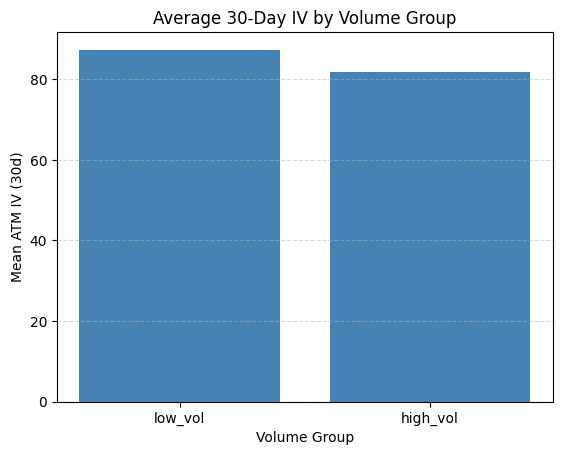

In [64]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
grouped = merge.groupby("vol_group")["atm_iv_30d"].mean()

plt.bar(grouped.index.astype(str), grouped.values, color="steelblue")
plt.title("Average 30-Day IV by Volume Group")
plt.xlabel("Volume Group")
plt.ylabel("Mean ATM IV (30d)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

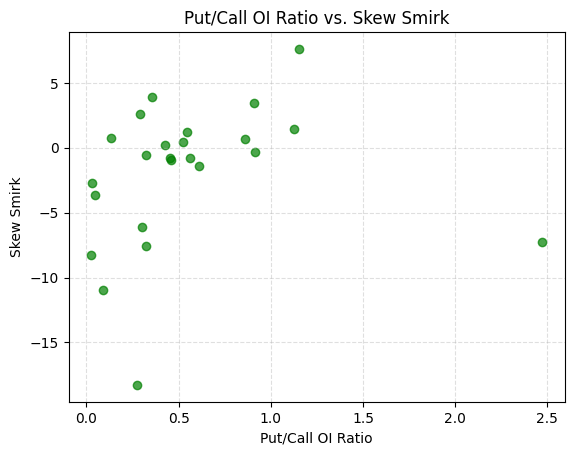

In [65]:
# Plot 2: Customized scatter plot of primary policy variables
plt.scatter(merge["pc_oi_ratio"], merge["skew_smirk"], color="green", alpha=0.7)
plt.title("Put/Call OI Ratio vs. Skew Smirk")
plt.xlabel("Put/Call OI Ratio")
plt.ylabel("Skew Smirk")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

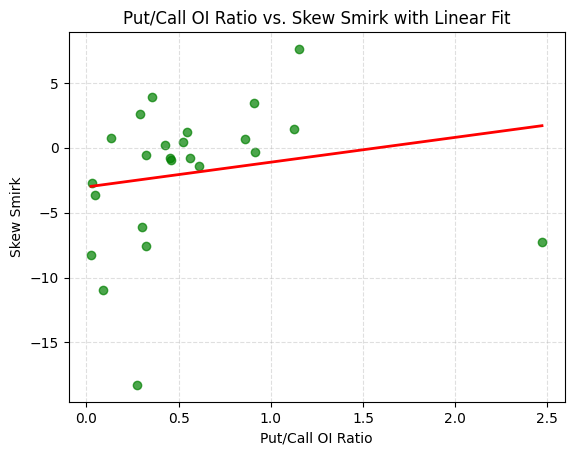

In [66]:
# Fit a simple linear regression and overlay the line of best fit
from sklearn.linear_model import LinearRegression
import numpy as np
X = merge["pc_oi_ratio"].values.reshape(-1, 1)
y = merge["skew_smirk"].values
model = LinearRegression()
model.fit(X, y)
x_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_fit = model.predict(x_fit)
plt.scatter(X, y, color="green", alpha=0.7)
plt.plot(x_fit, y_fit, color="red", linewidth=2)
plt.title("Put/Call OI Ratio vs. Skew Smirk with Linear Fit")
plt.xlabel("Put/Call OI Ratio")
plt.ylabel("Skew Smirk")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


- *Extra Credit: Write your visualization and regression interpretations here*

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.